# Why My R² Wouldn't Sit Still

This notebook goes with the post *The Day My R² Wouldn't Sit Still*.

**The question.** How much of the variation I saw could the train/test split
explain on its own?

**The method.** Fit the same model thousands of times. Change nothing except the
random split. Then look at the range of R² values that come out.

**The data.** The medical cost personal dataset. 1,338 rows, one per
policyholder, with age, sex, BMI, number of children, smoker status, region and
annual charges. I used the copy on Kaggle. Save it as `insurance.csv` in the same
folder as this notebook.

Run this top to bottom on a fresh kernel. That is not a throwaway instruction.
It is the whole point of the post.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

import sklearn, sys
print(f"python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")

python       3.12.2
numpy        1.26.4
pandas       2.2.2
scikit-learn 1.5.1


I print the version numbers on purpose. Different library versions across
machines was one of my suspects for the original problem. If you run this and get
different results, the first thing to check is whether your versions match mine.

## Load the data

The cell below prints the working directory if it cannot find the file. Almost
every "file not found" error is Python looking in the wrong folder, not a typo in
the filename.

In [2]:
CSV = Path("insurance.csv")

if not CSV.exists():
    print(f"Not found. Working directory is: {Path.cwd()}")
    print(f"Files here: {sorted(p.name for p in Path.cwd().iterdir())}")
    raise FileNotFoundError(CSV)

df = pd.read_csv(CSV)
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Build the model

My part of the project asked whether smoking and a high BMI multiply each other
rather than just adding up. So alongside the normal predictors there is an
interaction term: smoker status times BMI.

Sex and region are categorical, so they get one-hot encoded. I drop the first
level of each to avoid perfect collinearity between the dummy columns.

In [4]:
def build_design_matrix(df):
    df = df.copy()
    df["smoker_bin"] = (df["smoker"] == "yes").astype(int)
    df["smoker_bmi"] = df["smoker_bin"] * df["bmi"]   # the interaction term

    X = pd.get_dummies(
        df[["age", "bmi", "children", "sex", "region", "smoker_bin", "smoker_bmi"]],
        columns=["sex", "region"],
        drop_first=True,
    ).astype(float)
    y = df["charges"].astype(float)
    return X, y


X, y = build_design_matrix(df)
print(f"{X.shape[0]} rows, {X.shape[1]} predictors")
list(X.columns)

1338 rows, 9 predictors


['age',
 'bmi',
 'children',
 'smoker_bin',
 'smoker_bmi',
 'sex_male',
 'region_northwest',
 'region_southeast',
 'region_southwest']

## One split, run twice

Setting `random_state=None` means the split is random every time. That is the bug,
recreated on purpose.

Run the next cell. Then run it again.

In [9]:
rng = np.random.default_rng(20260906)

def fit_once(X, y, test_size=0.2):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size,
        random_state=int(rng.integers(0, 2**31 - 1))
    )
    return LinearRegression().fit(X_tr, y_tr).score(X_te, y_te)


print(f"first  run: {fit_once(X, y):.4f}")
print(f"second run: {fit_once(X, y):.4f}")

first  run: 0.8222
second run: 0.8230


Same code, same data, same cell, two different answers. Nothing changed in
between. That is the entire problem in two lines.

## Where do my two numbers fall?

Two hundred splits is enough to see the shape. It is not enough to say anything
precise about the tails. For that I run it ten thousand times, which takes a few
seconds and lets me put a real number on each of the two values I saw that night.

In [10]:
N_SPLITS = 10_000
MY_VALUES = [0.86, 0.91]

scores = np.array([fit_once(X, y) for _ in range(N_SPLITS)])

lo, hi = np.percentile(scores, [2.5, 97.5])
print(f"min / max     : {scores.min():.4f} / {scores.max():.4f}")
print(f"mean (sd)     : {scores.mean():.4f} ({scores.std():.4f})")
print(f"95% of splits : {lo:.4f} to {hi:.4f}")

for v in MY_VALUES:
    pct = (scores < v).mean() * 100
    hits = int((scores >= v).sum())
    print(f"{v:.2f} -> {pct:5.1f}th percentile | reached in {hits:>5} of {N_SPLITS:,} splits")

min / max     : 0.6955 / 0.9188
mean (sd)     : 0.8367 (0.0283)
95% of splits : 0.7772 to 0.8869
0.86 ->  79.3th percentile | reached in  2067 of 10,000 splits
0.91 ->  99.9th percentile | reached in    10 of 10,000 splits


## The chart

The two dashed lines are the numbers I actually saw. Each one is labelled with
what the ten thousand runs above say about it.

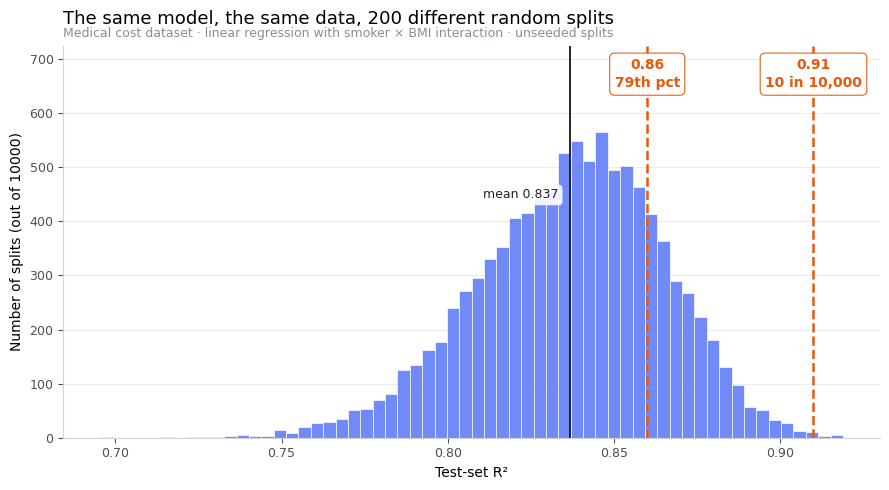

In [11]:
BLUE, ORANGE, INK, GREY = "#4C6EF5", "#E8590C", "#212529", "#868E96"

# the labels are computed from the data, not typed in by hand
labels = {
    v: f"{v:.2f}\n{(scores < v).mean() * 100:.0f}th pct"
       if (scores >= v).sum() > N_SPLITS * 0.05
       else f"{v:.2f}\n{int((scores >= v).sum())} in {N_SPLITS:,}"
    for v in MY_VALUES
}

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(scores, bins=60, color=BLUE, alpha=0.8, edgecolor="white", linewidth=0.6)

# add headroom first so the labels cannot overlap the bars
ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
top = ax.get_ylim()[1]

for v in MY_VALUES:
    ax.axvline(v, color=ORANGE, linestyle="--", linewidth=1.8, zorder=3)
    ax.annotate(
        labels[v], xy=(v, top * 0.97), ha="center", va="top",
        fontsize=10, color=ORANGE, fontweight="bold", linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=ORANGE, lw=0.8, alpha=0.95),
        zorder=4,
    )

ax.axvline(scores.mean(), color=INK, linewidth=1.4, zorder=3)
ax.annotate(
    f"mean {scores.mean():.3f}", xy=(scores.mean(), top * 0.62),
    xytext=(-8, 0), textcoords="offset points", ha="right", va="center",
    fontsize=9, color=INK,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9), zorder=4,
)

ax.set_xlabel("Test-set R²", fontsize=10)
ax.set_ylabel(f"Number of splits (out of {N_SPLITS})", fontsize=10)
ax.set_title("The same model, the same data, 200 different random splits",
             fontsize=13, pad=16, loc="left")
ax.text(0, 1.015,
        "Medical cost dataset · linear regression with smoker × BMI interaction · unseeded splits",
        transform=ax.transAxes, fontsize=9, color=GREY, va="bottom")

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CED4DA")
ax.tick_params(colors="#495057", labelsize=9)
ax.grid(axis="y", alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("r2_distribution.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

The label switches format on its own. A value sitting inside the main body of the
distribution gets a percentile. A value out in the tail gets a raw count instead,
because "18 times in 10,000" is much clearer than "99.8th percentile".

One small thing worth copying: `facecolor="white"` on the save. Without it the PNG
has a transparent background, and the axis labels vanish on a dark page.

## What I should have reported

The fix is not to find a better single split. It is to stop relying on one.

Cross-validation fits the model on several different partitions of the data and
averages the results, so no single lucky slice can flatter you. With a fixed seed
it gives the same answer every time.

In [12]:
cv = cross_val_score(LinearRegression(), X, y, cv=10, scoring="r2")

print(f"10-fold CV scores : {np.round(cv, 3)}")
print(f"mean (sd)         : {cv.mean():.4f} ({cv.std():.4f})")
print()
print(f"single-split range: {scores.min():.3f} to {scores.max():.3f}")
print(f"CV fold range     : {cv.min():.3f} to {cv.max():.3f}")

10-fold CV scores : [0.874 0.849 0.821 0.757 0.868 0.896 0.862 0.773 0.84  0.827]
mean (sd)         : 0.8367 (0.0419)

single-split range: 0.696 to 0.919
CV fold range     : 0.757 to 0.896


Notice that the individual folds still vary. Cross-validation does not remove the
variation. It reports it, which is the honest version. How much the folds differ
from each other tells you how confident you are allowed to be.

## Takeaway

A number that changes when you run it again is not a finding yet.

Fix every source of randomness, the model as well as the split. Restart the kernel
and run the whole notebook before you trust anything. Report an average across
folds along with its spread, instead of one split that happened to look good.

The same discipline is what separates a real backtest from a lucky one, which is
where I am taking this next.